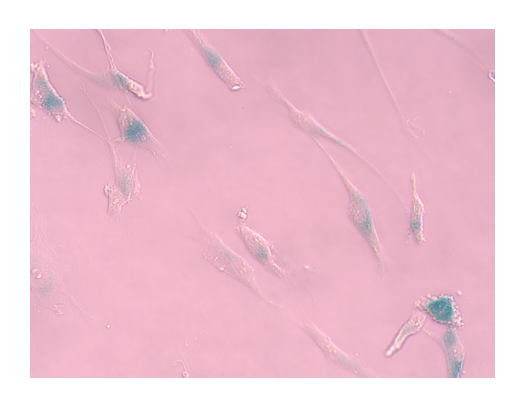

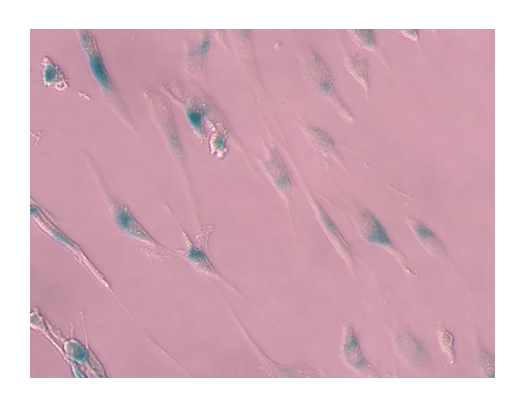

In [1]:
import numpy as np
import time, os, sys
from urllib.parse import urlparse
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline
mpl.rcParams['figure.dpi'] = 300
from cellpose import utils, io

#Añadido por mi para que carguen las imágenes de una carpeta
import os
from PIL import Image

# I will download images from website
#urls = ['http://www.cellpose.org/static/images/img02.png',
 #       'http://www.cellpose.org/static/images/img03.png',
  #      'http://www.cellpose.org/static/images/img05.png']

#files = ['./CellPose_test/test/000_img.png']
files = ['./Imagenes_para_entrenamiento/IL6_1/Image_1033.jpg']


"""
#Lo saqué de Bing
import os
from PIL import Image

def cargar_imagenes(ruta_carpeta):
    imagenes = []
    for nombre_archivo in os.listdir(ruta_carpeta):
        if nombre_archivo.endswith('.jpg') or nombre_archivo.endswith('.png'):  # Asegúrate de poner aquí todos los formatos que quieras cargar
            ruta_imagen = os.path.join(ruta_carpeta, nombre_archivo)
            imagen = Image.open(ruta_imagen)
            imagenes.append(imagen)
    return imagenes

# Uso de la función
imagenes = cargar_imagenes('ruta/a/tu/carpeta')
"""

imagenes = []

ruta_carpeta = './Imagenes_para_entrenamiento/IL6_1'

#i = 0
for nombre_archivo in os.listdir(ruta_carpeta):
    # Asegúrate de poner aquí todos los formatos que quieras cargar
    if nombre_archivo.endswith('.jpg'): # or nombre_archivo.endswith('.png'): 
        #print("Entra en el bucle")
        ruta_imagen = os.path.join(ruta_carpeta, nombre_archivo)
        #print(ruta_imagen)
        #imagen = Image.open(ruta_imagen)
        #print(imagen)
        #imagenes.append(imagen)
        imagenes.append(ruta_imagen)
  
#for url in urls:
 #   parts = urlparse(url)
  #  filename = os.path.basename(parts.path)
   # if not os.path.exists(filename):
    #    sys.stderr.write('Downloading: "{}" to {}\n'.format(url, filename))
     #   utils.download_url_to_file(url, filename)
    #files.append(filename)

# REPLACE FILES WITH YOUR IMAGE PATHS
# files = ['img0.tif', 'img1.tif']

# view 1 image
img = io.imread(files[-1])

#Añadido por mi tras mirar en Bing
img = img / np.amax(img)
#plt.imshow(tu_imagen)

img2 = io.imread(imagenes[-1])


#img2 = img2 / np.amax(img2)


plt.figure(figsize=(2,2))
plt.imshow(img)
plt.axis('off')
plt.show()

plt.figure(figsize=(2,2))
plt.imshow(img2)
plt.axis('off')
plt.show()


In [8]:
print(imagenes)

['./Imagenes_para_entrenamiento/IL6_1/Image_1039.jpg', './Imagenes_para_entrenamiento/IL6_1/Image_1030.jpg', './Imagenes_para_entrenamiento/IL6_1/Image_1037.jpg', './Imagenes_para_entrenamiento/IL6_1/Image_1035.jpg', './Imagenes_para_entrenamiento/IL6_1/Image_1029.jpg', './Imagenes_para_entrenamiento/IL6_1/Image_1036.jpg', './Imagenes_para_entrenamiento/IL6_1/Image_1034.jpg', './Imagenes_para_entrenamiento/IL6_1/Image_1032.jpg', './Imagenes_para_entrenamiento/IL6_1/Image_1033.jpg', './Imagenes_para_entrenamiento/IL6_1/Image_1031.jpg', './Imagenes_para_entrenamiento/IL6_1/Image_1038.jpg']


In [2]:
# RUN CELLPOSE

from cellpose import models, io

# DEFINE CELLPOSE MODEL
# model_type='cyto3' or model_type='nuclei'
model = models.Cellpose(gpu=False, model_type='cyto3')

# define CHANNELS to run segementation on
# grayscale=0, R=1, G=2, B=3
# channels = [cytoplasm, nucleus]
# if NUCLEUS channel does not exist, set the second channel to 0
# channels = [0,0]
# IF ALL YOUR IMAGES ARE THE SAME TYPE, you can give a list with 2 elements
# channels = [0,0] # IF YOU HAVE GRAYSCALE
# channels = [2,3] # IF YOU HAVE G=cytoplasm and B=nucleus
# channels = [2,1] # IF YOU HAVE G=cytoplasm and R=nucleus

# or if you have different types of channels in each image
channels = [[2,3], [0,0], [0,0]]

# if diameter is set to None, the size of the cells is estimated on a per image basis
# you can set the average cell `diameter` in pixels yourself (recommended) 
# diameter can be a list or a single number for all images

# you can run all in a list e.g.
# >>> imgs = [io.imread(filename) in for filename in files]
# >>> masks, flows, styles, diams = model.eval(imgs, diameter=None, channels=channels)
# >>> io.masks_flows_to_seg(imgs, masks, flows, diams, files, channels)
# >>> io.save_to_png(imgs, masks, flows, files)

# or in a loop
#for chan, filename in zip(channels, files): #files es del viejo donde solo se usa la 33
for chan, filename in zip(channels, imagenes):
    img = io.imread(filename)
    masks, flows, styles, diams = model.eval(img2, diameter=None, channels=chan)

    # save results so you can load in gui
    io.masks_flows_to_seg(img2, masks, flows, filename, channels=chan, diams=diams)

    # save results as png
    io.save_to_png(img2, masks, flows, filename)

100%|██████████████████████████████████████| 25.3M/25.3M [00:10<00:00, 2.42MB/s]
100%|██████████████████████████████████████| 3.54k/3.54k [00:00<00:00, 6.49MB/s]


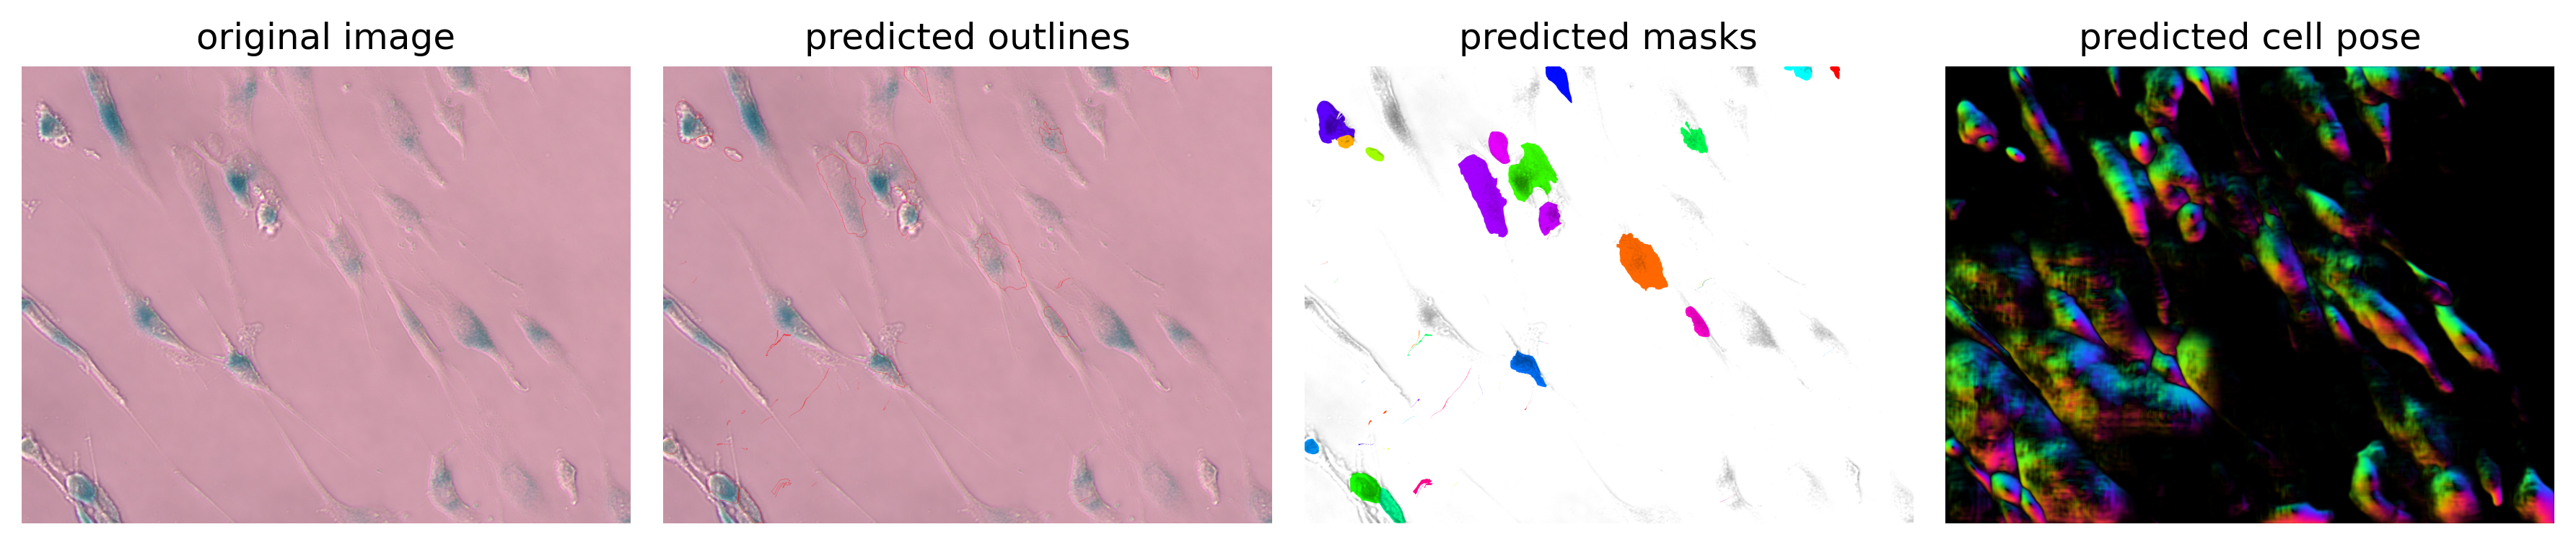

In [3]:
# DISPLAY RESULTS
from cellpose import plot

fig = plt.figure(figsize=(12,5))

#Añadido por mi tras mirar en Bing
img = img / np.amax(img)
#plt.imshow(tu_imagen)

plot.show_segmentation(fig, img2, masks, flows[0], channels=chan)
plt.tight_layout()
plt.show()